## 1. Setup and Imports

In [51]:
import os
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import random

# Paths
BASE_DIR = Path("../data")
SECTIONS_DIR = BASE_DIR / "quiz_sections"
OUTPUT_DIR = BASE_DIR / "individual_signs"

print(f"Sections directory: {SECTIONS_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

# Find all test directories
if SECTIONS_DIR.exists():
    test_dirs = sorted([d for d in SECTIONS_DIR.iterdir() if d.is_dir()])
    print(f"\nFound {len(test_dirs)} test directories")
else:
    print(f"ERROR: {SECTIONS_DIR} does not exist!")
    test_dirs = []

Sections directory: ..\data\quiz_sections
Output directory: ..\data\individual_signs

Found 20 test directories


# Approach 1: Border Detection

Detects horizontal and vertical borders to separate rows and columns.

## Parameters

In [52]:
# TWEAK THESE PARAMETERS
TOP_MARGIN = 50
BOTTOM_MARGIN = 20
LEFT_MARGIN = 50
RIGHT_MARGIN = 20
DARKNESS_THRESHOLD_MULTIPLIER = 1.75  # Higher = stricter detection
MIN_LINE_THICKNESS = 5  # Minimum pixels for a valid border

EXPECTED_ROWS = 2
EXPECTED_COLS = 8

## Functions

In [53]:
def detect_horizontal_borders(img, top_margin=0, bottom_margin=0):
    """Detect horizontal black lines (borders between rows)."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    height = gray.shape[0]
    gray_region = gray[top_margin:height-bottom_margin, :]
    row_darkness = np.mean(gray_region, axis=1)
    threshold = np.mean(row_darkness) - DARKNESS_THRESHOLD_MULTIPLIER * np.std(row_darkness)
    dark_rows = np.where(row_darkness < threshold)[0] + top_margin
    
    borders = []
    if len(dark_rows) > 0:
        current_cluster = [dark_rows[0]]
        for i in range(1, len(dark_rows)):
            if dark_rows[i] - dark_rows[i-1] <= 2:
                current_cluster.append(dark_rows[i])
            else:
                if len(current_cluster) >= MIN_LINE_THICKNESS:
                    borders.append(int(np.mean(current_cluster)))
                current_cluster = [dark_rows[i]]
        if len(current_cluster) >= MIN_LINE_THICKNESS:
            borders.append(int(np.mean(current_cluster)))
    
    return borders, row_darkness


def detect_vertical_borders(img, top=0, bottom=None, left_margin=0, right_margin=0):
    """Detect vertical black lines (borders between columns)."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if bottom is None:
        bottom = gray.shape[0]
    width = gray.shape[1]
    
    row_region = gray[top:bottom, left_margin:width-right_margin]
    col_darkness = np.mean(row_region, axis=0)
    threshold = np.mean(col_darkness) - DARKNESS_THRESHOLD_MULTIPLIER * np.std(col_darkness)
    dark_cols = np.where(col_darkness < threshold)[0] + left_margin
    
    borders = []
    if len(dark_cols) > 0:
        current_cluster = [dark_cols[0]]
        for i in range(1, len(dark_cols)):
            if dark_cols[i] - dark_cols[i-1] <= 2:
                current_cluster.append(dark_cols[i])
            else:
                if len(current_cluster) >= MIN_LINE_THICKNESS:
                    borders.append(int(np.mean(current_cluster)))
                current_cluster = [dark_cols[i]]
        if len(current_cluster) >= MIN_LINE_THICKNESS:
            borders.append(int(np.mean(current_cluster)))
    
    return borders, col_darkness


def calculate_boxes_border_detection(img):
    """Calculate sign boxes using border detection."""
    img_height, img_width = img.shape[0], img.shape[1]
    
    h_borders, _ = detect_horizontal_borders(img, TOP_MARGIN, BOTTOM_MARGIN)
    v_borders, _ = detect_vertical_borders(
        img, TOP_MARGIN, img_height-BOTTOM_MARGIN, LEFT_MARGIN, RIGHT_MARGIN
    )
    
    # Row boundaries
    if len(h_borders) == 0:
        row_separator = img_height // 2
    else:
        row_separator = h_borders[len(h_borders) // 2] if len(h_borders) > 1 else h_borders[0]
    
    row_boundaries = [
        (TOP_MARGIN, row_separator),
        (row_separator, img_height - BOTTOM_MARGIN)
    ]
    
    # Column boundaries
    col_x_positions = [LEFT_MARGIN] + v_borders + [img_width - RIGHT_MARGIN]
    col_x_positions = sorted(set(col_x_positions))
    
    if len(col_x_positions) < 9:
        usable_width = img_width - LEFT_MARGIN - RIGHT_MARGIN
        col_width = usable_width / EXPECTED_COLS
        col_x_positions = [int(LEFT_MARGIN + i * col_width) for i in range(EXPECTED_COLS + 1)]
    elif len(col_x_positions) > 9:
        col_x_positions = col_x_positions[:EXPECTED_COLS + 1]
    
    # Create boxes
    boxes = []
    for y_start, y_end in row_boundaries:
        for col_idx in range(min(EXPECTED_COLS, len(col_x_positions) - 1)):
            x_start = col_x_positions[col_idx]
            x_end = col_x_positions[col_idx + 1]
            boxes.append((x_start, y_start, x_end, y_end))
    
    return boxes

# Approach 2: Fixed Grid

Uses fixed proportions based on margins and equal division.

## Parameters

In [54]:
# TWEAK THESE PARAMETERS
FIXED_TOP_MARGIN = 90
FIXED_BOTTOM_MARGIN = 10
FIXED_LEFT_MARGIN = 75
FIXED_RIGHT_MARGIN = 25
FIXED_HORIZONTAL_SPACING = 2
FIXED_VERTICAL_SPACING = 2

## Functions

In [55]:
def calculate_boxes_fixed_grid(img):
    """Calculate sign boxes using fixed grid division."""
    img_height, img_width = img.shape[0], img.shape[1]
    
    usable_height = img_height - FIXED_TOP_MARGIN - FIXED_BOTTOM_MARGIN
    usable_width = img_width - FIXED_LEFT_MARGIN - FIXED_RIGHT_MARGIN
    
    cell_width = usable_width // EXPECTED_COLS
    cell_height = usable_height // EXPECTED_ROWS
    
    boxes = []
    for row in range(EXPECTED_ROWS):
        for col in range(EXPECTED_COLS):
            x_start = FIXED_LEFT_MARGIN + col * cell_width + FIXED_HORIZONTAL_SPACING // 2
            y_start = FIXED_TOP_MARGIN + row * cell_height + FIXED_VERTICAL_SPACING // 2
            x_end = x_start + cell_width - FIXED_HORIZONTAL_SPACING
            y_end = y_start + cell_height - FIXED_VERTICAL_SPACING
            boxes.append((x_start, y_start, x_end, y_end))
    
    return boxes

# Approach 3: Hybrid (Border Detection + Fixed Grid Fallback)

Tries border detection first, falls back to fixed grid if quality is poor.

## Parameters

In [56]:
# Quality thresholds
MIN_HORIZONTAL_BORDERS = 1
MIN_VERTICAL_BORDERS = 5
MAX_VERTICAL_BORDERS = 12
MAX_POSITION_VARIANCE_RATIO = 0.3  # Lower = stricter spacing consistency

## Functions

In [57]:
def evaluate_border_quality(h_borders, v_borders, img_width):
    """
    Evaluate border detection quality.
    Returns: (is_good, reason)
    """
    reasons = []
    
    if len(h_borders) < MIN_HORIZONTAL_BORDERS:
        reasons.append(f"Horizontal: {len(h_borders)}<{MIN_HORIZONTAL_BORDERS}")
    
    if len(v_borders) < MIN_VERTICAL_BORDERS:
        reasons.append(f"Vertical: {len(v_borders)}<{MIN_VERTICAL_BORDERS}")
    elif len(v_borders) > MAX_VERTICAL_BORDERS:
        reasons.append(f"Vertical: {len(v_borders)}>{MAX_VERTICAL_BORDERS}")
    
    if len(v_borders) >= 2:
        spacings = [v_borders[i+1] - v_borders[i] for i in range(len(v_borders)-1)]
        variance_ratio = np.std(spacings) / np.mean(spacings) if np.mean(spacings) > 0 else float('inf')
        if variance_ratio > MAX_POSITION_VARIANCE_RATIO:
            reasons.append(f"Spacing variance: {variance_ratio:.2f}>{MAX_POSITION_VARIANCE_RATIO}")
    
    return len(reasons) == 0, "; ".join(reasons) if reasons else "OK"


def calculate_boxes_hybrid(img):
    """
    Hybrid approach: Try border detection, fallback to fixed grid.
    Returns: (boxes, method, reason)
    """
    img_height, img_width = img.shape[0], img.shape[1]
    
    # Try border detection
    h_borders, _ = detect_horizontal_borders(img, TOP_MARGIN, BOTTOM_MARGIN)
    v_borders, _ = detect_vertical_borders(
        img, TOP_MARGIN, img_height-BOTTOM_MARGIN, LEFT_MARGIN, RIGHT_MARGIN
    )
    
    is_good, reason = evaluate_border_quality(h_borders, v_borders, img_width)
    
    if is_good:
        boxes = calculate_boxes_border_detection(img)
        return boxes, "border", reason
    else:
        boxes = calculate_boxes_fixed_grid(img)
        return boxes, "fixed", reason

# Testing & Comparison

Select approach and test on all images.

In [72]:
# ============================================================================
# SELECT APPROACH TO TEST
# ============================================================================
APPROACH = "hybrid"  # Options: "border", "fixed", "hybrid"
# ============================================================================

def crop_signs(signs_img_path, output_dir, test_name, approach="hybrid"):
    """
    Crop signs using selected approach.
    Returns: (saved_paths, method_info)
    """
    img = cv2.imread(str(signs_img_path))
    if img is None:
        return [], "error"
    
    # Get boxes based on approach
    if approach == "border":
        boxes = calculate_boxes_border_detection(img)
        method_info = "border"
    elif approach == "fixed":
        boxes = calculate_boxes_fixed_grid(img)
        method_info = "fixed"
    elif approach == "hybrid":
        boxes, method, reason = calculate_boxes_hybrid(img)
        method_info = f"{method} ({reason})"
    else:
        return [], "invalid_approach"
    
    if boxes is None or len(boxes) != 16:
        return [], f"error: {len(boxes) if boxes else 0} boxes"
    
    saved_paths = []
    for i, (x_start, y_start, x_end, y_end) in enumerate(boxes):
        cropped = img[y_start:y_end, x_start:x_end]
        filename = f"{test_name}_sign_{i+1:02d}.png"
        output_path = output_dir / filename
        cv2.imwrite(str(output_path), cropped)
        saved_paths.append(output_path)
    
    return saved_paths, method_info


# Process all tests
output_dir = OUTPUT_DIR / f"approach_{APPROACH}"
if output_dir.exists():
    import shutil
    shutil.rmtree(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

stats = {"total": 0, "success": 0, "failed": 0, "methods": {}}
print(f"Processing with: {APPROACH.upper()}")
print("="*70)

for test_dir in test_dirs:
    test_name = test_dir.name
    signs_dir = test_dir / "SIGNS"
    
    if not signs_dir.exists():
        continue
    
    signs_files = list(signs_dir.glob("*.png"))
    if not signs_files:
        continue
    
    try:
        test_output_dir = output_dir / test_name
        test_output_dir.mkdir(parents=True, exist_ok=True)
        
        saved, method_info = crop_signs(signs_files[0], test_output_dir, test_name, APPROACH)
        
        stats["total"] += 1
        if len(saved) == 16:
            stats["success"] += 1
            print(f"✓ {test_name}: {len(saved)} signs | {method_info}")
            
            # Track method statistics for hybrid
            if APPROACH == "hybrid":
                method_key = method_info.split()[0]
                stats["methods"][method_key] = stats["methods"].get(method_key, 0) + 1
        else:
            stats["failed"] += 1
            print(f"✗ {test_name}: {method_info}")
    
    except Exception as e:
        stats["failed"] += 1
        print(f"✗ {test_name}: {str(e)}")

print("\n" + "="*70)
print(f"RESULTS: {stats['success']}/{stats['total']} successful")
if APPROACH == "hybrid" and stats["methods"]:
    print(f"Methods: Border={stats['methods'].get('border', 0)}, Fixed={stats['methods'].get('fixed', 0)}")
print(f"Output: {output_dir}")
print("="*70)

Processing with: HYBRID
✓ test-01: 16 signs | fixed (Horizontal: 0<1; Vertical: 1<5)
✓ test-02: 16 signs | fixed (Horizontal: 0<1; Vertical: 0<5)
✓ test-03: 16 signs | fixed (Horizontal: 0<1; Vertical: 0<5)
✓ test-04: 16 signs | fixed (Horizontal: 0<1; Vertical: 0<5)
✓ test-05: 16 signs | fixed (Horizontal: 0<1; Vertical: 0<5)
✓ test-06: 16 signs | fixed (Horizontal: 0<1; Vertical: 0<5)
✓ test-07: 16 signs | fixed (Horizontal: 0<1; Vertical: 0<5)
✓ test-08: 16 signs | fixed (Horizontal: 0<1; Vertical: 0<5)
✓ test-09: 16 signs | fixed (Horizontal: 0<1; Vertical: 2<5)
✓ test-10: 16 signs | fixed (Horizontal: 0<1; Vertical: 1<5)
✓ test-11: 16 signs | fixed (Horizontal: 0<1; Vertical: 1<5)
✓ test-12: 16 signs | fixed (Horizontal: 0<1; Vertical: 2<5)
✓ test-13: 16 signs | fixed (Horizontal: 0<1; Vertical: 1<5)
✓ test-14: 16 signs | fixed (Horizontal: 0<1; Vertical: 1<5)
✓ test-15: 16 signs | fixed (Horizontal: 0<1; Vertical: 0<5)
✓ test-16: 16 signs | fixed (Horizontal: 0<1; Vertical: 1<5)


## Compare Approaches (Optional)

Run this to compare all three approaches side by side on a sample image.

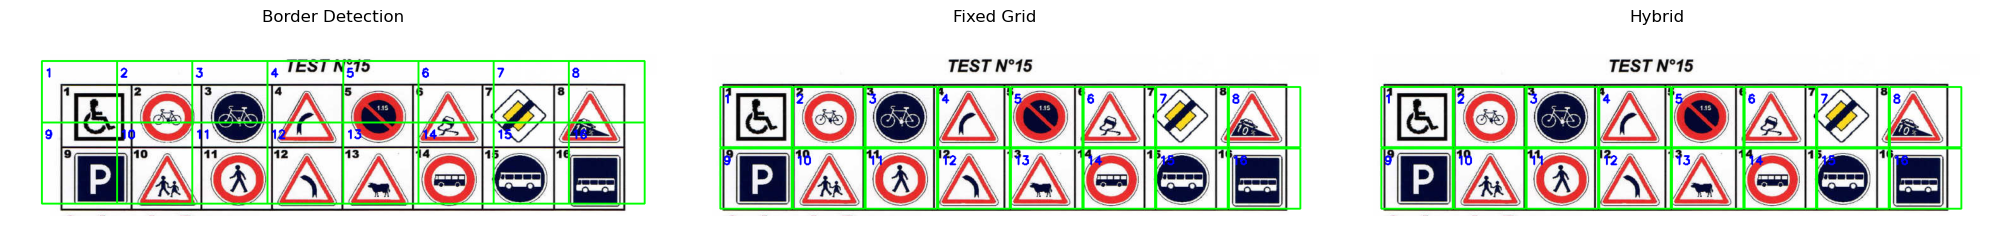

Comparison on: test-15_signs.png


In [66]:
# Compare all three approaches on a single test image
if test_dirs:
    sample_test = test_dirs[14]
    sample_img_path = list((sample_test / "SIGNS").glob("*.png"))[0]
    sample_img = cv2.imread(str(sample_img_path))
    
    approaches = {
        "Border Detection": calculate_boxes_border_detection(sample_img),
        "Fixed Grid": calculate_boxes_fixed_grid(sample_img),
        "Hybrid": calculate_boxes_hybrid(sample_img)[0]
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for idx, (name, boxes) in enumerate(approaches.items()):
        img_copy = sample_img.copy()
        for i, (x1, y1, x2, y2) in enumerate(boxes):
            cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img_copy, str(i+1), (x1+5, y1+25), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
        
        axes[idx].imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
        axes[idx].set_title(name)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    print(f"Comparison on: {sample_img_path.name}")